> 📝 **Planning note (author use -- remove before publishing)**
>
> **Intended contents:** clock drift correction, deck-pressure check, chop deployment/recovery, outlier removal (filtering, thresholding, hand editing); then the same for the SBE record.
>
> **To do:**
> - ~~Produce the AT200 edited file~~ (done -- cells at the end).
> - Fix the heading `## DO the same for the other dataset` (caps) and give that section a real introduction -- it is an important step, not an afterthought.
> - Cell 20: `moored.chop_deck(ds,)# indices= (100, 30000))` -- trailing comma and a commented-out argument. Tidy before publishing.
> - Decide whether despiking `PSAL` rather than `CNDC` is what you want to teach (see review note).

<img src="../../data/images/hiaoos_learning_moored.png" width="300" align="right">

# Postprocessing and QC (Part 1): Chopping and removing outliers

Here, we show some examples of **basic postprocessing functions**: 

- Clock corrections
- Chop deployment and recovery


We also illustrate **outlier removal**:

- Filtering
- Thresholding
- Hand editing

Drift and offset corrections are covered in the next notebook.

*Notebook 4 of 10 in the series*  
[← 3. Loading data (SBE)](./03_load_data_seabird_instruments.ipynb) · [5. Post-processing & QC II →](./05_post_proc_qc_offset_and_drift.ipynb)

In [8]:
from kval.data import moored
import matplotlib.pyplot as plt
%matplotlib widget

___

## Load the time series

Let's start by loading the file we produced in [step #2](./02_load_data_rbr_instruments.ipynb).

> **Note:** `moored.load_nc` is a thin wrapper around `xarray.open_dataset`. The one thing it changes is the default: it loads with `decode_cf=False`, so `TIME` stays as the raw number stored in the file rather than being auto-converted to a `datetime64` object. We keep it that way here -- the `kval` functions below accept either form. Notebook 6 covers how and when to convert.

In [9]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_from_raw.nc')

We will also make a copy of the dataset before applying edits so we can compare:

In [10]:
ds0 = ds.copy(deep = True)

`(deep=True)` makes sure that we are making a copy that will not be affected by any changes we make to `ds`.

___

## Adjust for a known clock drift

The internal clock of the instrument can drift over time while deployed. With modern RBR instruments this rarely amounts to more than some minutes of drift over years of deployment - but we should compensate for the drift in any event.

Once you know the difference between the instrument clock and true time on recovery, we can adjust the time stamp of the instrument to compensate, assuming that time drift occurs linearly over the deployment period.

Whether we correct or not will typically depend on whether we think the correction matters for any scientific application. In general, it is good to apply a correction if you can - it can only make things better.  

Below, we imagine that we have observed that the instrument clock *leads* true time by 1 minutes and 34 seconds.

> *If the instrument clock* lags *true time, use negative values for* `seconds`, `minutes` *etc).*

In [11]:
ds = moored.adjust_time_for_drift(ds, minutes=1, seconds=34)

The updated `ds` should now be corrected so that the instrument clock is in line with true time on recovery.

____

### Check deck pressure

Often, these instrument begins sampling before they are put in the water - and are stopped some time after they are back on deck. We typically want to remove data from recovery and deployment from our analysis. Note, however, that for CTDs, deck measurements provide an opportunity to check that the pressure sensor is working correctly.

Essentially, we expect that `PRES`(*sea pressure*, i.e. absolute pressure minus an offset for atmospheric pressure) should be near zero when the instrument is out of the water. Some deviation is acceptable, and some is expected due to fluctuations in atmospheric pressure. When to correct depends on the accuracy you require; for most oceanographic applications small deviations are expected and acceptable, but if your deck pressure offset differs from zero by more than 1 dbar you may consider making corrections.

Here, we will simply use the `moored.plot` function, change variable to `PRES`, and zoom in on the start and/or end of the record.

In [12]:
moored.plot(ds)

We only have data *before* deployment - in this case the sea pressure is around 0.1 dbar. We consider this acceptable and will not apply any further corrections to pressure.

___

## Remove deployment/deck time



Now we want to chop the time series so as to only include ocean measurements.  

#### Chop by time

If we know when the instrument was deployed/recovered, we can simply chop away measurements before/after a certain time stamp.

In the following example, we chop away all measurements after 14:00 UTC, Apr 17 2022:

In [13]:
ds = moored.chop_by_time(ds, end_time = '2022-04-23 14:00')

Chopped dataset to time range start to 2022-04-23 14:00, reducing from 23903 to 23768 samples.


We can also try to detect recovery/deployment based on the pressure data. This usually works, but not always - so make sure you inspect the chop before applying it. 

`moored.chop_deck` tries to detect which time period to include by looking for the first/last measurements where pressure is within a SD of the median. 

The user is shown the proposed cut and can choose to decline or execute by entering `y` or `n`.

Note that you can also choose to automatically accept the cut by setting `auto_accept = True`. Useful if you are already sure that the function does what you want.


`ds = moored.chop_deck(ds, indices= (200, 20420))` will retain only measurements between indices 200 and 20420.

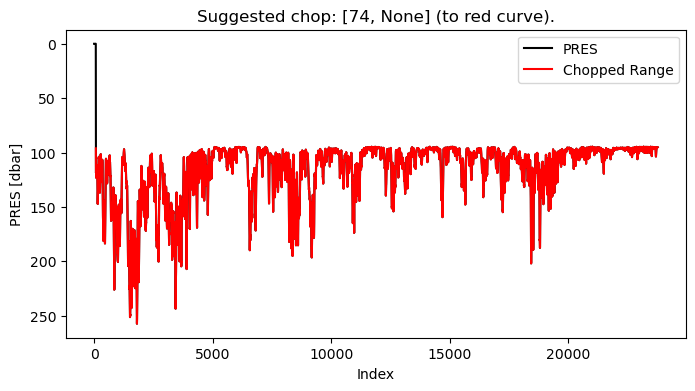

Suggested chop: [74, None] (to red curve).


Accept (y/n)?:  y


Chopping to idx: [np.int64(74), None]
Chopped 74 samples using -> [np.int64(74), None] (total samples 23768 -> 23694)


In [14]:
ds = moored.chop_deck(ds,)# indices= (100, 30000))

## Remove outliers

Below we apply one outlier-removal method (despiking by rolling filter) to the dataset, and then save the result. The two methods after that -- thresholding and hand editing -- are shown as *examples only*: we assign their output to separate datasets (`ds_thr`, `ds_handedit`) so that `ds` is left untouched.

If you want a change to stick, assign it back to `ds`:

    ds = moored.despike_rolling(ds, ...)     # change is kept

If you only want to experiment, assign it somewhere else:

    ds_test = moored.despike_rolling(ds, ...)   # ds is unchanged

### Filtering

> ✏️ **Review note** — this despikes `PSAL` only. `PSAL` in the RBR file is derived from `CNDC`, `TEMP` and `PRES` -- so if anything downstream recalculates salinity (as notebook 5 does with `calculate_PSAL`), the despiking silently disappears. Worth either despiking `CNDC` instead, or saying explicitly in the text that this is a demonstration on the derived variable.

Removed 43 points from PSAL after despiking along dimension TIME.


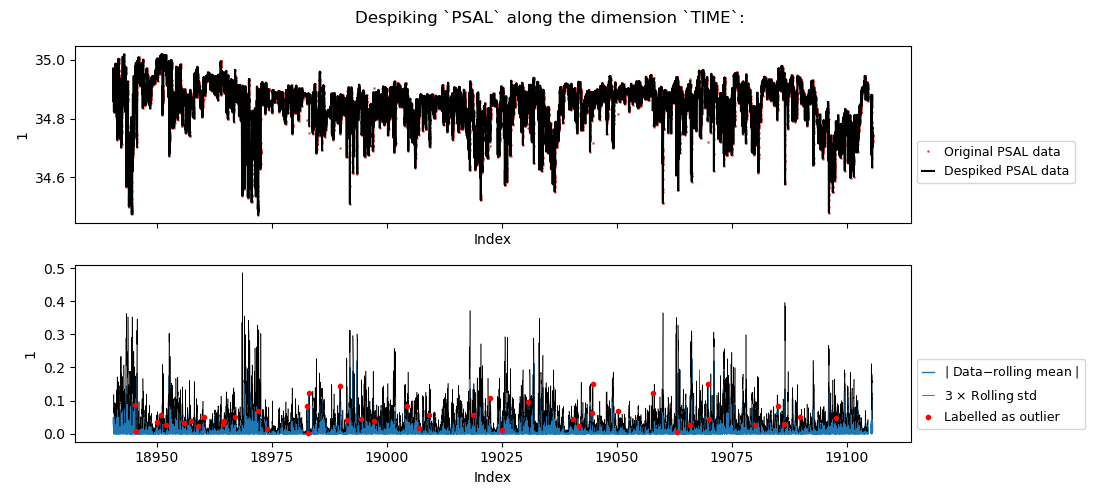

In [15]:
ds = moored.despike_rolling(ds, variable='PSAL', window_size=13, n_std=3, plot = True, verbose = True)

## Other outlier editing 

The two methods below are shown as examples only - their output goes to separate datasets, so `ds` is unaffected.

### Thresholding

In [16]:
ds_thr = moored.threshold_pick(ds)

### Hand editing

Output()

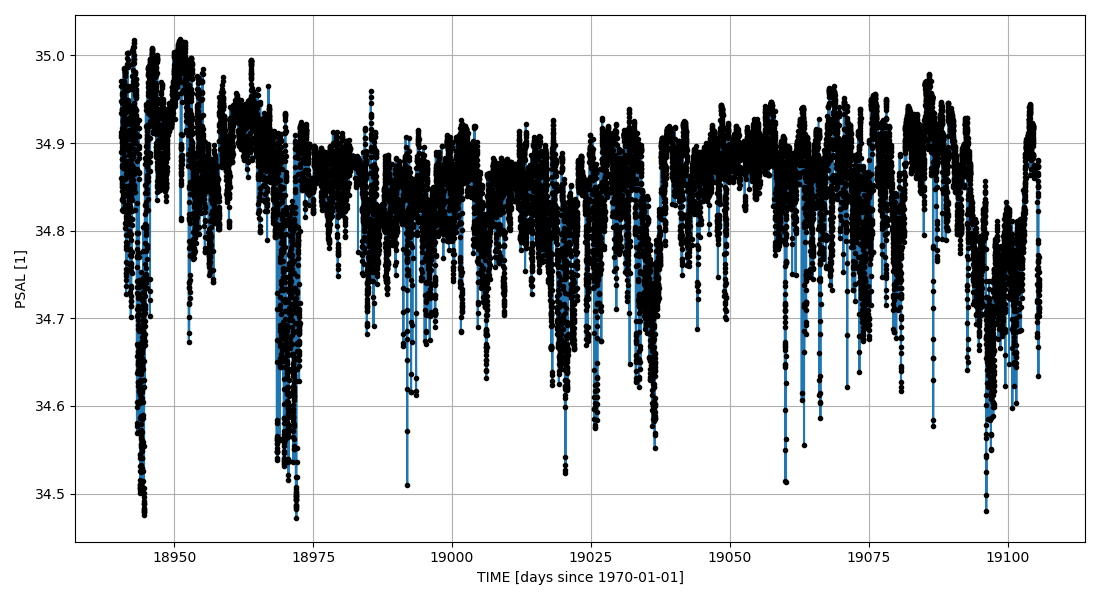

In [17]:
ds_handedit = moored.hand_remove_points(ds, 'PSAL')

In [18]:
moored.plot(ds_handedit)

### Save to nc

We will save the file as it now is.

In [21]:
moored.to_netcdf(ds, '../../data/moored_CTD_test_data/intermediate_data/', 'AT800_21_22_CONCERTO_60595_99m_edited.nc')

Updated history attribute. Current content:
---
2021-11-08 - 2022-04-24: Data collection.
2026-09-25: Data read from .rsk file to xarray Dataset using pyRSKtools+kval.
2026-09-25: Creation of this netcdf file.
---


The file ../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc already exists. Overwrite? (y/n):  y


File ../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc overwritten.
Exported NetCDF file as: ../../data/moored_CTD_test_data/intermediate_data/AT800_21_22_CONCERTO_60595_99m_edited.nc


___

## Doing the same for the other instrument

- Why this is here: the AT200/SBE record needs the same treatment before it is used in notebooks 7-10.
- What is being done more briefly this time, and what is being skipped (no clock drift correction, no despiking) -- and whether that is a choice or a simplification.

> ✏️ Placeholder -- short prose needed.

Load the netCDF file from notebook #3

In [22]:
ds = moored.load_nc('../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_from_raw.nc')

Quickly remove deck time

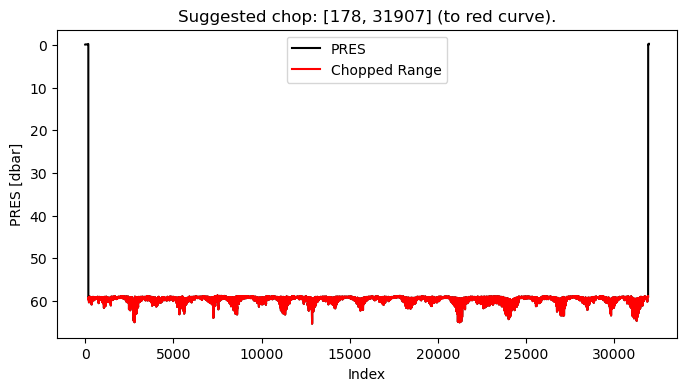

Suggested chop: [178, 31907] (to red curve).


Accept (y/n)?:  y


Chopping to idx: [np.int64(178), np.int64(31907)]
Chopped 222 samples using -> [np.int64(178), np.int64(31907)] (total samples 31951 -> 31729)


In [23]:
ds = moored.chop_deck(ds)

.. and save to NetCDF:

In [24]:
moored.to_netcdf(ds, '../../data/moored_CTD_test_data/intermediate_data/', 'AT200_21_22_SBE37_20773_49m_edited.nc')

Updated history attribute. Current content:
---
2021-11-07 - 2022-10-06: Data collection.
2022-10-06: Processed to .cnv using SBE software.
2026-09-25: Post-processing.
2026-09-25: Creation of this netcdf file.
---


The file ../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc already exists. Overwrite? (y/n):  y


File ../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc overwritten.
Exported NetCDF file as: ../../data/moored_CTD_test_data/intermediate_data/AT200_21_22_SBE37_20773_49m_edited.nc


___

**Next:** [5. Post-processing & QC II →](./05_post_proc_qc_offset_and_drift.ipynb)